In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

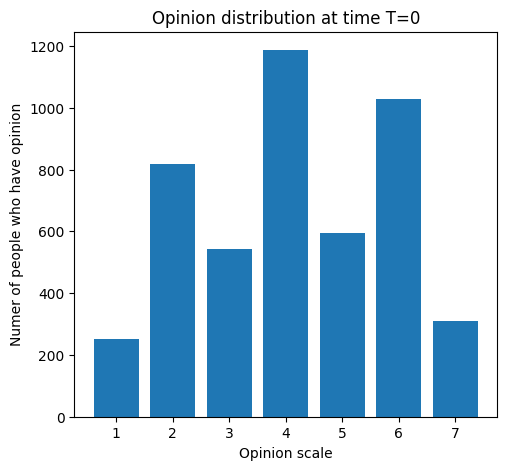

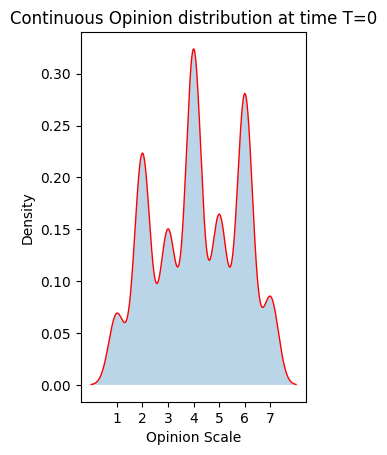

In [29]:
#import data 
data = pd.read_csv("anes_timeseries_2024_csv_20250808/anes_timeseries_2024_csv_20250808.csv", usecols = ['V241177'])

#filter data to remove votes corresponding to abstaining or errors
remove = [-9, -4, 99] # "Refused", "Error", "Havent thought much about this"
filtered = data[~data['V241177'].isin(remove)]
removed = data[data['V241177'].isin(remove)]

#convert to array
arr = filtered['V241177'].to_numpy()

plt.figure(figsize=(12, 5))

# Discrete
plt.subplot(1, 2, 1)
plt.hist(arr, bins=np.arange(arr.min() - 0.5, arr.max() + 1.5, 1), rwidth=0.8)
plt.xlabel('Opinion scale')
plt.ylabel('Numer of people who have opinion')
plt.title(f"Opinion distribution at time T=0")
plt.show()


data_points = np.repeat(arr, 1)
kde = stats.gaussian_kde(data_points)
continuous_samples = kde.resample(5000)[0] 

# Continuous
plt.subplot(1, 2, 2)
x_continuous = np.linspace(arr.min() - 1, arr.max() + 1, 5000)
plt.plot(x_continuous, kde(x_continuous), 'r-', linewidth=1)
plt.fill_between(x_continuous, kde(x_continuous), alpha=0.3)
plt.xlabel('Opinion Scale')
plt.ylabel('Density')
plt.title(f"Continuous Opinion distribution at time T=0")
plt.xticks(range(1, 8))
plt.show()